In [17]:
!uv --version
!uv pip list

uv 0.11.17 (a33a629d6 2026-05-28 x86_64-pc-windows-msvc)


In [18]:
!uv pip install opencv-python

Resolved 2 packages in 1.72s
Prepared 2 packages in 23.12s
Installed 2 packages in 2.45s
 + numpy==2.4.6
 + opencv-python==4.13.0.92


In [19]:
!uv pip install requests

Resolved 5 packages in 752ms
Installed 5 packages in 252ms
 + certifi==2026.5.20
 + charset-normalizer==3.4.7
 + idna==3.17
 + requests==2.34.2
 + urllib3==2.7.0


In [21]:
!uv pip install matplotlib

Resolved 11 packages in 4.25s
Prepared 7 packages in 7.59s
Installed 10 packages in 1.19s
 + contourpy==1.3.3
 + cycler==0.12.1
 + fonttools==4.63.0
 + kiwisolver==1.5.0
 + matplotlib==3.10.9
 + packaging==26.2
 + pillow==12.2.0
 + pyparsing==3.3.2
 + python-dateutil==2.9.0.post0
 + six==1.17.0


success!


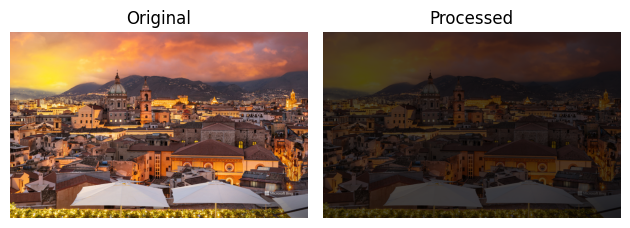

In [68]:
# 试卷4 图片增强应用
# 安装 opencv-python 库 使用 cv2 加载本地图片 使用 matplotlib 库 展示图片
# 问题1 封装函数 对图片做 亮度 对比度 调节，对入参进行 归一化 ，测试参数: 30, 50

import cv2
import matplotlib.pyplot as plt

# 读取的图像是 BGR格式
img = cv2.imread('images/exam_4_demo.jpg') 

# plt.figure()
# plt.imshow(img)
# plt.axis('off')
# plt.show()

def adjust_brightness_contrast(image, brightness, contrast):
    """
    实现对图像亮度与对比度调节，入参归一化
    入参:
        brightness 亮度：int [0,-100]
        contrast: 对比度：int [0,-100]    
    """
    float_brightness = brightness / 100.0
    float_contrast = brightness / 100.0
    result = cv2.convertScaleAbs(image, float_brightness, float_contrast)


    print('success!')
    return result

adjust_result = adjust_brightness_contrast(img, 30, 50)

# 显示原图

# 创建 1行 2列 并 定位到 第 1 个位置
plt.subplot(1, 2, 1)
img_after = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_after)
plt.axis('off')
plt.title('Original')
# 显示处理图

plt.subplot(1, 2, 2)
result_after = cv2.cvtColor(adjust_result, cv2.COLOR_BGR2RGB)
plt.imshow(result_after)
plt.axis('off')
plt.title('Processed')
plt.tight_layout()
plt.show()


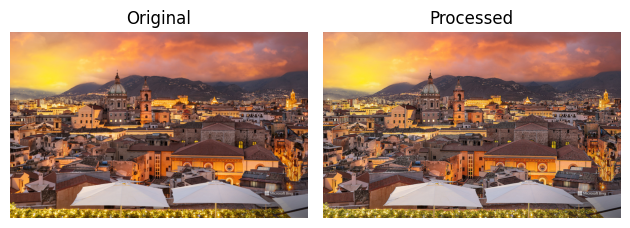

In [69]:
# 定义锐化核 对图像进行锐化处理
import numpy as np
# 定义锐化核
sharpen_kernel = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
result = cv2.filter2D(img, -1, sharpen_kernel)

plt.subplot(1, 2, 1)
img_after = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_after)
plt.axis('off')
plt.title('Original')

# 显示处理图片
plt.subplot(1, 2, 2)
result_after = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
plt.imshow(result_after)
plt.axis('off')
plt.title('Processed')

plt.tight_layout()


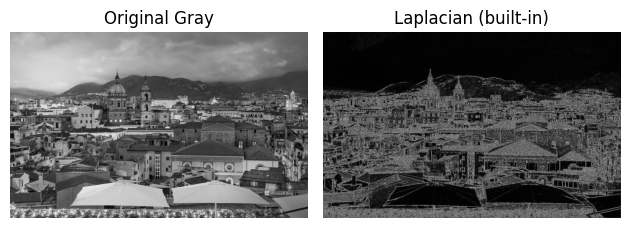

In [70]:
# 拉普拉斯 通常在灰度图上计算
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

result = cv2.Laplacian(gray, cv2.CV_64F, ksize=3)
result_abs = np.uint8(np.abs(result))

plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.title('Original Gray')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result_abs, cmap='gray')
plt.title('Laplacian (built-in)')
plt.axis('off')

plt.tight_layout()
plt.show()


success!
adjust success
gaussinanblur success


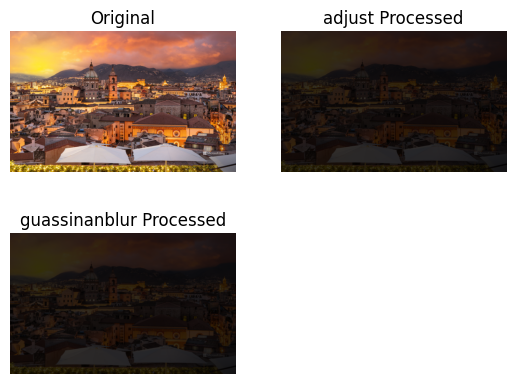

In [74]:
def apply_filter_sub_gaussianblur(image):
    result = cv2.GaussianBlur(image, (5,5), sigmaX=1.5)
    return result
    

def apply_filter(image):
    # 显示原图
    plt.subplot(2, 2, 1)
    image_after = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    plt.imshow(image_after)
    plt.title('Original')
    plt.axis('off')

    
    adjust_result = adjust_brightness_contrast(img, 20, 40)
    if adjust_result is not None:
        print('adjust success')
        plt.subplot(2, 2, 2)
        adjust_result_after = cv2.cvtColor(adjust_result, cv2.COLOR_BGR2RGB)
        plt.imshow(adjust_result_after)
        plt.title('adjust Processed')
        plt.axis('off')
        
        gaussianblur_result = apply_filter_sub_gaussianblur(adjust_result)
        if gaussianblur_result is not None:
            print('gaussinanblur success')
            plt.subplot(2, 2, 3)
            gaussianblur_result_after = cv2.cvtColor(gaussianblur_result, cv2.COLOR_BGR2RGB)
            plt.imshow(gaussianblur_result_after)
            plt.title('guassinanblur Processed')
            plt.axis('off')
        else:
            print('gaussinanblur failed')            
    else:
        print('adjust failed')
        
    
        
# 调用 apply_filter
apply_filter(img)